# CFProto-CFE Training: MNIST (alle 3 Ziffernpaare)
**Datensatz:** MNIST, alle drei Ziffernpaare (3-8, 4-9, 5-6) werden in **einem** Durchlauf
nacheinander ausgewertet.
**Modell:** Custom ResNet-18 (MNIST-Variante, siehe `mnist-resnet18-training.ipynb`)
**Methode:** CFProto nach Van Looveren & Klaise (2020) -- Prototypen-gefuehrte
Counterfactual-Optimierung im Pixelraum (Elastic-Net-Regularisierung + Prototyp-Loss).
Aufgebaut nach demselben Muster wie die FCVE-/Mirror-CFE-/Wachter-MNIST-Notebooks und der
CFProto-Kernlogik aus `cfproto-fire.ipynb` -- 1:1 uebernommen, nur auf 1-Kanal/32x32/
binaeres Ziffernpaar angepasst (kein EBPG, da MNIST keine Bounding-Boxes hat --
dokumentierte Abweichung wie bei den anderen MNIST-Notebooks).

CFProto hat wie Wachter **kein Training** eines CFE-Modells/Decoders -- pro Paar wird nur
der eingefrorene Klassifikator geladen, die Klassen-Prototypen (Mittleres Encoding der
K=20 naechsten Instanzen je Klasse) werden aus einer Trainings-Stichprobe berechnet, und
die CFEs werden pro Bild direkt im Pixelraum optimiert. Am Ende werden die Metriken (L1,
Sparsity, LPIPS, FID, Validity, Denoised Validity, Coverage, Efficiency) ueber alle drei
Paare **gemittelt** ausgegeben.

### Outputs
- `./cfproto_<PAIR_KEY>.png` -- Beispiel-Visualisierung pro Paar
- `./metrics_summary.csv` -- alle 3 Paare + eine `MEAN`-Zeile mit dem Durchschnitt


## 1. Imports & globale Konfiguration

In [1]:
import os
import struct
import time
import numpy as np
from array import array
from os.path import join
from tqdm import tqdm
from collections import OrderedDict
from functools import partial

import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms

torch.manual_seed(2024)
np.random.seed(2024)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Geraet:', DEVICE)

# -- Alle drei Ziffernpaare -- werden unten in einer Schleife nacheinander durchlaufen --
TASK_PAIRS = {'38': (3, 8), '49': (4, 9), '56': (5, 6)}
METHOD = 'CFProto'

# -- Pfade (MNIST-Rohdaten, IDX-Format, wie auf Kaggle bereitgestellt) --------
INPUT_PATH = '/kaggle/input/datasets/hojjatk/mnist-dataset'
TRAIN_IMAGES_PATH = join(INPUT_PATH, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
TRAIN_LABELS_PATH = join(INPUT_PATH, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
TEST_IMAGES_PATH  = join(INPUT_PATH, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
TEST_LABELS_PATH  = join(INPUT_PATH, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')
OUT_DIR   = '/kaggle/working/'

IMAGE_SIZE = 32                      # 28 -> 32, konsistent mit FCVE-/Mirror-CFE-/Wachter-MNIST
MNIST_MEAN = [0.5]
MNIST_STD  = [0.5]

# CFProto-Hyperparameter (identisch zu cfproto-fire.ipynb)
CFP_C       = 1.0
CFP_BETA    = 0.1
CFP_THETA   = 100.0
CFP_KAPPA   = 0.0
CFP_LR      = 0.01
CFP_MAXITER = 200
CFP_CSTEPS  = 5
PROTO_K     = 20

# Fester Eval-Satz (auch global, damit die Aggregation am Ende darauf zugreifen kann)
EVAL_SEED     = 42
N_EVAL_IMAGES = 80


Geraet: cuda


## 2. Dataset (global -- MNIST wird einmal komplett geladen)

In [2]:
class MnistDataloader(object):
    """IDX-Format-Loader fuer MNIST (liest die rohen Kaggle-Dateien direkt, kein Download noetig)."""
    def __init__(self, training_images_filepath, training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath

    def read_images_labels(self, images_filepath, labels_filepath):
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError(f'Magic number mismatch, expected 2049, got {magic}')
            labels = array("B", file.read())
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError(f'Magic number mismatch, expected 2051, got {magic}')
            image_data = array("B", file.read())
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img
        return images, labels

    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train), (x_test, y_test)


mnist_dataloader = MnistDataloader(TRAIN_IMAGES_PATH, TRAIN_LABELS_PATH, TEST_IMAGES_PATH, TEST_LABELS_PATH)
(x_train_all, y_train_all), (x_test_all, y_test_all) = mnist_dataloader.load_data()
x_train_all = np.array(x_train_all, dtype=np.uint8)
y_train_all = np.array(y_train_all, dtype=np.int64)
x_test_all  = np.array(x_test_all,  dtype=np.uint8)
y_test_all  = np.array(y_test_all,  dtype=np.int64)
print(f'MNIST geladen (IDX-Format) -- Train: {x_train_all.shape}  Test: {x_test_all.shape}')


def filter_and_remap(images, labels, d0, d1):
    """Behaelt nur Bilder von d0/d1, remapped Labels auf {0,1} (0=d0, 1=d1)."""
    mask = (labels == d0) | (labels == d1)
    imgs_f = images[mask]
    lbls_f = np.where(labels[mask] == d0, 0, 1).astype(np.int64)
    return imgs_f, lbls_f


class MNISTPairDataset(Dataset):
    """Nimmt bereits gefilterte (images, labels)-Arrays (uint8 28x28, Labels 0/1) und wendet
    die torchvision-Transform-Pipeline an. Gibt zusaetzlich einen synthetischen Dateinamen
    zurueck, damit die Downstream-Funktionen (Metriken, Visualisierung) strukturell zu den
    Fire-/X-Ray-Notebooks passen (dort: echter Dateiname)."""
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx], mode='L')
        label = int(self.labels[idx])
        if self.transform is not None:
            img = self.transform(img)
        fname = f'{idx:06d}.png'
        return img, label, fname

print('MnistDataloader + MNISTPairDataset definiert OK')


MNIST geladen (IDX-Format) -- Train: (60000, 28, 28)  Test: (10000, 28, 28)
MnistDataloader + MNISTPairDataset definiert OK


## 3. Klassifikator-Architektur (global -- Gewichte werden pro Paar geladen)

In [3]:
class Conv2dAuto(nn.Conv2d):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.padding = (self.kernel_size[0] // 2, self.kernel_size[1] // 2)

conv3x3 = partial(Conv2dAuto, kernel_size=3, bias=False)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.blocks   = nn.Identity()
        self.shortcut = nn.Identity()
    def forward(self, x):
        residual = self.shortcut(x) if self.should_apply_shortcut else x
        x = self.blocks(x)
        x += residual
        return x
    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.out_channels

class ResNetResidualBlock(ResidualBlock):
    def __init__(self, in_channels, out_channels, expansion=1,
                 downsampling=1, conv=conv3x3, *args, **kwargs):
        super().__init__(in_channels, out_channels)
        self.expansion    = expansion
        self.downsampling = downsampling
        self.conv         = conv
        self.shortcut = (
            nn.Sequential(OrderedDict({
                'conv': nn.Conv2d(self.in_channels, self.expanded_channels,
                                  kernel_size=1, stride=self.downsampling, bias=False),
                'bn':   nn.BatchNorm2d(self.expanded_channels)
            }))
            if self.should_apply_shortcut else None
        )
    @property
    def expanded_channels(self):
        return self.out_channels * self.expansion
    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.expanded_channels

def conv_bn(in_channels, out_channels, conv, *args, **kwargs):
    return nn.Sequential(OrderedDict({
        'conv': conv(in_channels, out_channels, *args, **kwargs),
        'bn':   nn.BatchNorm2d(out_channels)
    }))

class ResNetBasicBlock(ResNetResidualBlock):
    expansion = 1
    def __init__(self, in_channels, out_channels, activation=nn.ReLU, *args, **kwargs):
        super().__init__(in_channels, out_channels, *args, **kwargs)
        self.blocks = nn.Sequential(
            conv_bn(self.in_channels, self.out_channels,
                    conv=self.conv, bias=False, stride=self.downsampling),
            activation(),
            conv_bn(self.out_channels, self.expanded_channels,
                    conv=self.conv, bias=False),
        )

class ResNetLayer(nn.Module):
    def __init__(self, in_channels, out_channels, block=ResNetBasicBlock,
                 n=1, *args, **kwargs):
        super().__init__()
        downsampling = 2 if in_channels != out_channels else 1
        self.blocks = nn.Sequential(
            block(in_channels, out_channels, *args, **kwargs,
                  downsampling=downsampling),
            *[block(out_channels * block.expansion, out_channels,
                    downsampling=1, *args, **kwargs) for _ in range(n - 1)]
        )
    def forward(self, x):
        return self.blocks(x)

class ResNetEncoder(nn.Module):
    """Gate-Defaults identisch zum Original-ResNet18 (Fire/X-Ray): kernel=7, stride=2,
    padding=3, pool=True. Bei 32x32-MNIST-Eingaben ergibt das die Pyramide
    f1@8 f2@4 f3@2 f4@1 (512 Kanaele) -- proportional identisch zu Fire (224->7)."""
    def __init__(self, in_channels=1, blocks_sizes=(64, 128, 256, 512),
                 depths=(2, 2, 2, 2), activation=nn.ReLU,
                 block=ResNetBasicBlock,
                 gate_kernel=7, gate_stride=2, gate_padding=3, gate_pool=True,
                 *args, **kwargs):
        super().__init__()
        self.blocks_sizes = blocks_sizes
        gate_layers = [
            nn.Conv2d(in_channels, blocks_sizes[0], kernel_size=gate_kernel,
                      stride=gate_stride, padding=gate_padding, bias=False),
            nn.BatchNorm2d(blocks_sizes[0]),
            activation(),
        ]
        if gate_pool:
            gate_layers.append(nn.MaxPool2d(kernel_size=3, stride=2, padding=1))
        self.gate = nn.Sequential(*gate_layers)
        self.in_out_block_sizes = list(zip(blocks_sizes, blocks_sizes[1:]))
        self.blocks = nn.ModuleList([
            ResNetLayer(blocks_sizes[0], blocks_sizes[0], n=depths[0],
                        activation=activation, block=block, *args, **kwargs),
            *[ResNetLayer(in_ch * block.expansion, out_ch, n=n,
                          activation=activation, block=block, *args, **kwargs)
              for (in_ch, out_ch), n in zip(self.in_out_block_sizes, depths[1:])]
        ])
    def forward(self, x):
        x = self.gate(x)
        for block in self.blocks:
            x = block(x)
        return x

class ResNetDecoder(nn.Module):
    def __init__(self, in_features, n_classes):
        super().__init__()
        self.avg     = nn.AdaptiveAvgPool2d((1, 1))
        self.decoder = nn.Linear(in_features, n_classes)
    def forward(self, x):
        x = self.avg(x)
        x = x.view(x.size(0), -1)
        x = self.decoder(x)
        return x

class ResNet(nn.Module):
    def __init__(self, in_channels, n_classes, *args, **kwargs):
        super().__init__()
        self.encoder = ResNetEncoder(in_channels, *args, **kwargs)
        self.decoder = ResNetDecoder(
            self.encoder.blocks[-1].blocks[-1].expanded_channels, n_classes
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

def build_classifier():
    # Gate UNVERAENDERT (Defaults oben) -- identische Architektur wie das
    # Klassifikator-Training in mnist-resnet18-training.ipynb.
    return ResNet(in_channels=1, n_classes=2, block=ResNetBasicBlock, depths=[2, 2, 2, 2])


def extract_features(model, images):
    """fmaps: (B,512,1,1) spatiale Feature Maps ; z_gap: (B,512) nach GAP."""
    fmaps_list = []
    hook = model.encoder.blocks[-1].register_forward_hook(
        lambda m, i, o: fmaps_list.append(o)
    )
    with torch.no_grad():
        _ = model(images)
    hook.remove()
    fmaps = fmaps_list[0]
    z_gap = F.adaptive_avg_pool2d(fmaps, (1,1)).flatten(1)
    return fmaps, z_gap

print('Klassifikator-Architektur definiert OK')


Klassifikator-Architektur definiert OK


## 4. Normalisierungs-Hilfsfunktionen (global)

In [4]:
def denormalise(tensor):
    """Funktioniert fuer 3D (C,H,W) und 4D (B,C,H,W) Tensoren."""
    if tensor.dim() == 3:
        mean = torch.tensor(MNIST_MEAN, device=tensor.device).view(1,1,1)
        std  = torch.tensor(MNIST_STD,  device=tensor.device).view(1,1,1)
    else:
        mean = torch.tensor(MNIST_MEAN, device=tensor.device).view(1,1,1,1)
        std  = torch.tensor(MNIST_STD,  device=tensor.device).view(1,1,1,1)
    return (tensor * std + mean).clamp(0, 1)

print('Normalisierungs-Hilfsfunktionen definiert (global) OK')


Normalisierungs-Hilfsfunktionen definiert (global) OK


## 5. CFProto Kernfunktionen (global)
Direkt aus `cfproto-fire.ipynb` uebernommen (`extract_embedding`, `compute_class_prototypes`,
`cfproto_loss`, `compute_cfproto`) -- nur `feature_range`/Mean-Std generisch ueber
`MNIST_MEAN`/`MNIST_STD` (1 Kanal statt 3), keine inhaltliche Aenderung der
Optimierungslogik. CFProto ist wie Wachter eine Pixelraum-Methode ohne Decoder.

In [5]:
def extract_embedding(model, images):
    """
    Extrahiert den 512-dim Embedding-Vektor (nach GlobalAvgPool, vor Classifier).
    Rueckgabe: (B, 512)
    """
    with torch.no_grad():
        features = model.encoder(images)                   # (B, 512, 1, 1) bei MNIST
        emb = F.adaptive_avg_pool2d(features, (1, 1))      # (B, 512, 1, 1)
        emb = emb.view(emb.size(0), -1)                    # (B, 512)
    return emb


def compute_class_prototypes(model, data_loader, device, K=20):
    """
    Berechnet Klassen-Prototypen nach Van Looveren & Klaise (2020).
    Prototyp = Mittleres Encoding der K naechsten Instanzen einer Klasse.
    Rueckgabe: dict {class_idx: prototype_tensor (512,)}
    """
    model.eval()
    all_embs   = []
    all_labels = []

    print('Berechne Embeddings fuer Prototypen...')
    for batch_imgs, batch_lbls, _ in tqdm(data_loader, desc='Embeddings'):
        batch_imgs = batch_imgs.to(device)
        emb = extract_embedding(model, batch_imgs)
        # Modell-Vorhersage fuer Label (predicted class, nicht GT)
        with torch.no_grad():
            logits = model(batch_imgs)
            preds  = logits.argmax(dim=1).cpu()
        all_embs.append(emb.cpu())
        all_labels.append(preds)

    all_embs   = torch.cat(all_embs,   dim=0)   # (N, 512)
    all_labels = torch.cat(all_labels, dim=0)   # (N,)

    prototypes = {}
    for cls in [0, 1]:
        mask     = (all_labels == cls)
        cls_embs = all_embs[mask]                # (M, 512)
        if cls_embs.size(0) == 0:
            print(f'  ⚠ Keine Embeddings fuer Klasse {cls}')
            continue
        if K is not None and cls_embs.size(0) > K:
            mean_emb = cls_embs.mean(dim=0, keepdim=True)
            dists    = torch.norm(cls_embs - mean_emb, dim=1)
            _, topk  = dists.topk(K, largest=False)
            cls_embs = cls_embs[topk]
        prototypes[cls] = cls_embs.mean(dim=0)   # (512,)
        print(f'  Prototyp Klasse {cls} ({CLASS_NAMES[cls]}): {cls_embs.size(0)} Samples')

    return prototypes, all_embs, all_labels


def cfproto_loss(xcf, x0, model, target_proto, source_class,
                 c=1.0, beta=0.1, theta=100.0, kappa=0.0):
    """
    CFProto Zielfunktion (Paper Eq. 6):
    L = c * L_pred + beta * L1 + L2 + theta * L_proto
    """
    delta = xcf - x0

    l1_loss = delta.abs().sum()
    l2_loss = (delta ** 2).sum()

    logits = model(xcf)
    probs  = torch.softmax(logits, dim=1)   # (B, 2)
    other_mask = torch.ones(probs.size(1), dtype=torch.bool)
    other_mask[source_class] = False
    p_source = probs[:, source_class]
    p_other  = probs[:, other_mask].max(dim=1).values
    lpred    = torch.clamp(p_source - p_other + kappa, min=-kappa).mean()

    features = model.encoder(xcf)                          # (B, 512, 1, 1) bei MNIST
    emb_xcf  = F.adaptive_avg_pool2d(features, (1, 1)).view(features.size(0), -1)  # (B, 512)
    proto    = target_proto.to(xcf.device).unsqueeze(0)    # (1, 512)
    lproto   = ((emb_xcf - proto) ** 2).sum(dim=1).mean()

    total = c * lpred + beta * l1_loss + l2_loss + theta * lproto
    return total, lpred.item(), l1_loss.item(), l2_loss.item(), lproto.item()


def compute_cfproto(
    model, images, device, prototypes,
    c=1.0, beta=0.1, theta=100.0, kappa=0.0,
    lr=0.01, max_iter=200, c_steps=5,
    feature_range=None
):

    model.eval()
    images = images.to(device)
    B      = images.size(0)

    # Feature range bestimmen (1 Kanal statt 3 -- generisch ueber MNIST_MEAN/STD)
    if feature_range is None:
        lo = torch.tensor([(0 - m) / s for m, s in zip(MNIST_MEAN, MNIST_STD)],
                           device=device).view(1, 1, 1, 1)
        hi = torch.tensor([(1 - m) / s for m, s in zip(MNIST_MEAN, MNIST_STD)],
                           device=device).view(1, 1, 1, 1)
    else:
        lo, hi = feature_range

    with torch.no_grad():
        logits        = model(images)
        probs_all     = torch.softmax(logits, dim=1)
        orig_probs    = probs_all[:, 1]
        source_labels = logits.argmax(dim=1)

    cfe_labels = 1 - source_labels   # Binaer: Ziel = andere Klasse

    xcf_batch = []

    for i in range(B):
        x0        = images[i:i+1].clone()           # (1, 1, H, W)
        src_cls   = source_labels[i].item()
        tgt_cls   = cfe_labels[i].item()
        tgt_proto = prototypes[tgt_cls].to(device)  # (512,)

        best_xcf  = x0.clone().detach()
        best_loss = float('inf')
        c_current = c

        for c_step in range(c_steps):
            xcf = x0.clone().detach().requires_grad_(True)
            optimizer = torch.optim.Adam([xcf], lr=lr)

            found_cf = False
            for it in range(max_iter):
                optimizer.zero_grad()

                with torch.no_grad():
                    xcf.clamp_(lo, hi)

                loss, lp, l1, l2, lpr = cfproto_loss(
                    xcf, x0, model, tgt_proto, src_cls,
                    c=c_current, beta=beta, theta=theta, kappa=kappa
                )
                loss.backward()
                optimizer.step()

                with torch.no_grad():
                    pred_cf = model(xcf).argmax(dim=1).item()
                if pred_cf == tgt_cls:
                    en_loss = beta * (xcf - x0).abs().sum() + ((xcf - x0) ** 2).sum()
                    if en_loss.item() < best_loss:
                        best_loss = en_loss.item()
                        best_xcf  = xcf.clone().detach()
                    found_cf = True

            if found_cf:
                c_current = c_current / 2.0
            else:
                c_current = c_current * 2.0

        xcf_batch.append(best_xcf)

    xcf_batch = torch.cat(xcf_batch, dim=0)   # (B, 1, H, W)
    return xcf_batch, cfe_labels, source_labels, orig_probs


def get_cfe_image_from_cfproto(images, xcf_batch):
    """
    CFProto ist eine Pixelraum-Methode: xcf_batch IST bereits das fertige
    Counterfactual-Bild. Wir denormalisieren Original und CFE direkt -- KEIN Decoder.
    Rueckgabe: orig_np, cfe_np -- beide (B, H, W, 1) in [0,1]
    """
    orig_np = denormalise(images.cpu()).permute(0, 2, 3, 1).numpy().clip(0, 1)
    cfe_np  = denormalise(xcf_batch.detach().cpu()).permute(0, 2, 3, 1).numpy().clip(0, 1)
    return orig_np, cfe_np


print('CFProto Funktionen definiert OK')


CFProto Funktionen definiert OK


## 6. Visualisierungsfunktion (global, ohne BBox -- MNIST hat keine)

In [6]:
def visualise_cfproto(model, images, labels, xcf_batch, cfe_labels, source_labels,
                      orig_probs, class_names, n_samples=4, save_path='cfproto.png'):
    """Drei-Panel Visualisierung pro Sample (ohne BBox-Overlay, da MNIST keine hat)."""
    model.eval()
    images    = images.to(DEVICE)
    xcf_batch = xcf_batch.to(DEVICE)
    n = min(n_samples, images.size(0))

    orig_np, cfe_np = get_cfe_image_from_cfproto(images[:n], xcf_batch[:n])

    with torch.no_grad():
        cf_logits     = model(xcf_batch[:n])
        cfe_probs_val = torch.softmax(cf_logits, dim=1)[:, 1].cpu().numpy()

    orig_probs_np = orig_probs[:n].detach().cpu().numpy()

    fig, axes = plt.subplots(n, 3, figsize=(9, n * 3.2))
    if n == 1:
        axes = axes[np.newaxis, :]
    col_titles = ['Original xᵢ', "CFE x' (Pixelraum)", "|x' − xᵢ| Differenz"]
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=10, fontweight='bold', pad=10)

    for i in range(n):
        orig_np_i = orig_np[i].squeeze(-1)
        cfe_np_i  = cfe_np[i].squeeze(-1)
        diff_np   = np.abs(cfe_np_i - orig_np_i)
        diff_np   = (diff_np - diff_np.min()) / (diff_np.max() + 1e-8)

        src_lbl  = source_labels[i].item(); cfe_lbl = cfe_labels[i].item()
        true_lbl = int(labels[i])
        flipped  = int(cfe_probs_val[i] >= 0.5) == cfe_lbl
        flip_col = 'limegreen' if flipped else 'tomato'
        flip_txt = '✓ Gekippt' if flipped else '✗ Nicht gekippt'
        pred_col = 'limegreen' if src_lbl == true_lbl else 'tomato'

        ax1 = axes[i, 0]; ax1.imshow(orig_np_i, cmap='gray')
        ax1.set_ylabel(f'Wahr: {class_names[true_lbl]}\nPred: {class_names[src_lbl]} ({orig_probs_np[i]:.1%})',
                       fontsize=8, color=pred_col, rotation=0, labelpad=70, va='center')
        ax1.axis('off')

        ax2 = axes[i, 1]; ax2.imshow(cfe_np_i, cmap='gray')
        ax2.set_xlabel(f'Ziel: {class_names[cfe_lbl]} ({cfe_probs_val[i]:.1%})\n{flip_txt}',
                       fontsize=8, color=flip_col)
        ax2.axis('off')

        ax3 = axes[i, 2]
        im = ax3.imshow(diff_np, cmap='hot', vmin=0, vmax=1)
        plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
        ax3.axis('off')

    plt.suptitle(f"CFProto-CFE — Paar {PAIR_KEY}\nGrün = Vorhersage gekippt  |  Rot = Vorhersage nicht gekippt",
                fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Gespeichert -> {save_path}')

print('CFProto Visualisierungsfunktion definiert OK')


CFProto Visualisierungsfunktion definiert OK


## 7. Metriken — Setup (global)

In [7]:
pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# METRIKEN — identisch mit FCVE-/Mirror-CFE-/Wachter-MNIST fuer direkten Vergleich.
# KEINE EBPG: MNIST hat keine Bounding-Boxes / Lokalisierungs-Ground-Truth wie
# Fire/X-Ray, daher entfaellt diese Metrik (dokumentierte Abweichung, wie bei
# den anderen MNIST-Notebooks).
# ══════════════════════════════════════════════════════════════════════════════
from scipy import linalg as scipy_linalg

try:
    import lpips
    lpips_fn = lpips.LPIPS(net='squeeze').to(DEVICE)
    lpips_fn.eval()
    LPIPS_AVAILABLE = True
    print('LPIPS geladen OK')
except ImportError:
    LPIPS_AVAILABLE = False
    print('LPIPS nicht verfuegbar -- pip install lpips')


def compute_l1(orig_np, cfe_np):
    """L1-Norm nach Wachter et al. (2017)."""
    diffs = np.abs(orig_np - cfe_np)
    l1_per_sample = diffs.sum(axis=(1,2,3)) / (orig_np.shape[1] * orig_np.shape[2] * orig_np.shape[3])
    return float(l1_per_sample.mean())


def compute_sparsity_rate(orig_np, cfe_np, threshold=1e-4):
    """Anteil der veraenderten Pixel nach Moreira et al. (2025)."""
    diff = np.abs(orig_np - cfe_np).mean(axis=-1)
    changed = (diff > threshold).astype(float)
    return float(changed.mean(axis=(1,2)).mean())


def _gray_to_rgb(t):
    """LPIPS/InceptionV3 erwarten 3 Kanaele -- Graustufen replizieren."""
    return t.repeat(1, 3, 1, 1) if t.shape[1] == 1 else t


def compute_lpips(orig_np, cfe_np):
    """LPIPS nach Zhang et al. (2018) mit SqueezeNet."""
    if not LPIPS_AVAILABLE:
        return None
    orig_t = torch.tensor(orig_np, dtype=torch.float32).permute(0,3,1,2).to(DEVICE) * 2 - 1
    cfe_t  = torch.tensor(cfe_np,  dtype=torch.float32).permute(0,3,1,2).to(DEVICE) * 2 - 1
    orig_t, cfe_t = _gray_to_rgb(orig_t), _gray_to_rgb(cfe_t)
    with torch.no_grad():
        scores = lpips_fn(orig_t, cfe_t)
    return float(scores.mean().cpu())


from torchvision.models import inception_v3

@torch.no_grad()
def extract_inception_features(imgs_np, batch_size=32):
    """Extrahiert 2048-dim InceptionV3 Features. imgs_np: (B, H, W, 1) in [0,1]"""
    if not hasattr(extract_inception_features, '_model'):
        model_inc = inception_v3(weights='DEFAULT', transform_input=False)
        model_inc.fc = nn.Identity()
        model_inc = model_inc.eval().to(DEVICE)
        extract_inception_features._model = model_inc
    inc = extract_inception_features._model
    feats = []
    for i in range(0, len(imgs_np), batch_size):
        batch = imgs_np[i:i+batch_size]
        t = torch.tensor(batch, dtype=torch.float32).permute(0,3,1,2).to(DEVICE)
        t = _gray_to_rgb(t)
        t = torch.nn.functional.interpolate(t, size=(299,299), mode='bilinear', align_corners=False)
        feats.append(inc(t).cpu().numpy())
    return np.concatenate(feats, axis=0)


def compute_fid(real_np, fake_np):
    """FID ueber InceptionV3 Features."""
    real_feats = extract_inception_features(real_np)
    fake_feats = extract_inception_features(fake_np)
    mu_r, mu_f = real_feats.mean(0), fake_feats.mean(0)
    sig_r = np.cov(real_feats, rowvar=False)
    sig_f = np.cov(fake_feats, rowvar=False)
    diff = mu_r - mu_f
    covmean, _ = scipy_linalg.sqrtm(sig_r @ sig_f, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(sig_r + sig_f - 2 * covmean))


def compute_validity(model, cfe_imgs_tensor, cfe_labels, denoise_sigma=None):
    """Validity nach Verma et al. (2022). Misst Klassenflip im Pixelraum."""
    from torchvision.transforms.functional import gaussian_blur
    model.eval()
    cfe_imgs_tensor = cfe_imgs_tensor.to(DEVICE)
    if denoise_sigma is not None:
        kernel_size = max(int(denoise_sigma * 6) | 1, 3)
        cfe_imgs_tensor = gaussian_blur(cfe_imgs_tensor, kernel_size=[kernel_size, kernel_size],
                                        sigma=[denoise_sigma, denoise_sigma])
    mean = torch.tensor(MNIST_MEAN, device=DEVICE).view(1,1,1,1)
    std  = torch.tensor(MNIST_STD,  device=DEVICE).view(1,1,1,1)
    cfe_norm = (cfe_imgs_tensor - mean) / std
    with torch.no_grad():
        preds = model(cfe_norm).argmax(dim=1).cpu()
    return float((preds == cfe_labels.cpu()).float().mean())


def compute_coverage(model, images, prototypes, n_runs=5):
    """Coverage nach Moreira et al. (2025): wie oft findet CFProto ein valides CF?"""
    images = images.to(DEVICE)
    valid_runs = []
    for run in range(n_runs):
        torch.manual_seed(run)
        xcf, c_lbls, s_lbls, o_probs = compute_cfproto(
            model, images, DEVICE, prototypes,
            c=CFP_C, beta=CFP_BETA, theta=CFP_THETA, kappa=CFP_KAPPA,
            lr=CFP_LR, max_iter=CFP_MAXITER, c_steps=CFP_CSTEPS
        )
        with torch.no_grad():
            preds = model(xcf.to(DEVICE)).argmax(dim=1).cpu()
        rate = (preds == c_lbls.cpu()).float().mean().item()
        valid_runs.append(rate)
    return float(np.mean(valid_runs)), float(np.std(valid_runs))


print('Metrik-Funktionen definiert OK')


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Setting up [LPIPS] perceptual loss: trunk [squeeze], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 59.0MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/squeeze.pth
LPIPS geladen OK
Metrik-Funktionen definiert OK


## 8. Pipeline pro Ziffernpaar
Alles Paar-Spezifische (Klassifikator laden, Prototypen berechnen, CFProto-CFE generieren,
Visualisierung, Metriken) steckt in dieser einen Funktion -- analog zu
`run_fcve_pipeline`/`run_mirror_pipeline`/`run_wachter_pipeline`, nur ohne Trainingsschritt
(CFProto optimiert wie Wachter pro Bild direkt im Pixelraum -- kein CFE-Modell, kein
Decoder).

In [9]:
def run_cfproto_pipeline(pair_key):
    global PAIR_KEY, DIGIT_PAIR, CLASS_NAMES
    PAIR_KEY = pair_key
    DIGIT_PAIR = TASK_PAIRS[PAIR_KEY]
    CLASS_NAMES = {0: str(DIGIT_PAIR[0]), 1: str(DIGIT_PAIR[1])}

    CLS_PATH_KAGGLE = f'/kaggle/input/models/alexandernigg/mnist-{PAIR_KEY}-cnn-v2/pytorch/default/1/best_model_{PAIR_KEY}.pth'
    CLS_PATH_LOCAL  = f'./best_model_{PAIR_KEY}.pth'
    CLS_PATH = CLS_PATH_KAGGLE if os.path.exists(CLS_PATH_KAGGLE) else CLS_PATH_LOCAL

    print('\n' + '#' * 70)
    print(f'# CFProto-CFE — Ziffernpaar {PAIR_KEY} {DIGIT_PAIR}')
    print('#' * 70)
    print('Klassifikator-Checkpoint vorhanden:', os.path.exists(CLS_PATH))



    # -- Dataset & Split (90/10, identischer Seed wie Klassifikator-Training) --
    eval_transforms = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(MNIST_MEAN, MNIST_STD),
    ])

    imgs_f, lbls_f = filter_and_remap(x_train_all, y_train_all, *DIGIT_PAIR)
    full_ds_eval = MNISTPairDataset(imgs_f, lbls_f, transform=eval_transforms)

    n_val   = int(len(full_ds_eval) * 0.1)     # 90/10, konsistent mit FCVE/Mirror-CFE/Wachter MNIST
    n_train = len(full_ds_eval) - n_val
    generator = torch.Generator().manual_seed(42)
    perm = torch.randperm(len(full_ds_eval), generator=generator).tolist()
    train_idx, val_idx = perm[:n_train], perm[n_train:]

    print(f'Klassen: {CLASS_NAMES}')
    print(f'Train (fuer Prototypen): {len(train_idx)}  Val (CF-Pool): {len(val_idx)}')

    BATCH_SIZE = 16
    test_dataset = Subset(full_ds_eval, val_idx)
    test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=False)

    # Kleiner Trainings-Loader fuer Prototyp-Berechnung (analog Fire: max. 2000 Samples)
    proto_indices = train_idx[:min(2000, len(train_idx))]
    proto_dataset = Subset(full_ds_eval, proto_indices)
    train_loader_proto = DataLoader(proto_dataset, batch_size=64, shuffle=False,
                                    num_workers=2, pin_memory=False)



    # -- Klassifikator laden (eingefroren) --
    checkpoint  = torch.load(CLS_PATH, map_location=DEVICE, weights_only=False)
    classifier  = build_classifier().to(DEVICE)
    classifier.load_state_dict(checkpoint['model_state_dict'])
    classifier.eval()
    for param in classifier.parameters():
        param.requires_grad = False
    print('Klassifikator geladen und eingefroren OK')
    print(f'Val Accuracy: {checkpoint.get("val_acc", "N/A")}')



    # -- Prototypen berechnen --
    prototypes, proto_embs, proto_labels = compute_class_prototypes(
        classifier, train_loader_proto, DEVICE, K=PROTO_K
    )
    print(f'\nPrototypen berechnet:')
    for cls, proto in prototypes.items():
        print(f'  Klasse {cls} ({CLASS_NAMES[cls]}): shape={proto.shape}, norm={proto.norm():.2f}')



    # -- Sanity Check -- Flip Rate (ein Batch) --
    sample_images, sample_labels, sample_fnames = next(iter(test_loader))
    xcf_batch, cfe_labels, source_labels, orig_probs = compute_cfproto(
        classifier, sample_images, DEVICE, prototypes,
        c=CFP_C, beta=CFP_BETA, theta=CFP_THETA, kappa=CFP_KAPPA,
        lr=CFP_LR, max_iter=CFP_MAXITER, c_steps=CFP_CSTEPS
    )
    with torch.no_grad():
        cf_preds = classifier(xcf_batch.to(DEVICE)).argmax(dim=1).cpu()
    flip_rate = (cf_preds == cfe_labels.cpu()).float().mean()
    print(f'Batch-Groesse   : {len(sample_labels)}')
    print(f'Flip Rate     : {flip_rate:.2%}  (Ziel: >80%)')
    if flip_rate < 0.8:
        print('\n⚠ Flip Rate niedrig — max_iter oder c_steps erhoehen')

    visualise_cfproto(
        model=classifier, images=sample_images, labels=sample_labels,
        xcf_batch=xcf_batch, cfe_labels=cfe_labels, source_labels=source_labels,
        orig_probs=orig_probs, class_names=CLASS_NAMES, n_samples=4,
        save_path=os.path.join(OUT_DIR, f'cfproto_{PAIR_KEY}.png')
    )



    # -- Batch-Evaluation -- Flip Rate ueber 10 Batches --
    n_batches, total_flip, total_images = 10, 0, 0
    for batch_imgs, batch_lbls, batch_fnames in tqdm(
            list(test_loader)[:n_batches], desc='CFProto Evaluation'):
        xcf, c_lbls, s_lbls, o_probs = compute_cfproto(
            classifier, batch_imgs, DEVICE, prototypes,
            c=CFP_C, beta=CFP_BETA, theta=CFP_THETA, kappa=CFP_KAPPA,
            lr=CFP_LR, max_iter=CFP_MAXITER, c_steps=CFP_CSTEPS
        )
        with torch.no_grad():
            preds = classifier(xcf.to(DEVICE)).argmax(dim=1).cpu()
        total_flip   += (preds == c_lbls.cpu()).sum().item()
        total_images += len(batch_lbls)
    print(f'\nFlip Rate (10 Batches): {total_flip}/{total_images} = {total_flip/total_images:.2%}')



    # -- Fester Eval-Satz fuer dieses Paar --
    EVAL_SEED_L, N_EVAL_IMAGES_L = 42, 80
    _val_idx = list(val_idx)
    _rng = np.random.RandomState(EVAL_SEED_L)
    _rng.shuffle(_val_idx)
    eval_indices = _val_idx[:N_EVAL_IMAGES_L]

    eval_dataset = Subset(full_ds_eval, eval_indices)
    eval_loader  = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=False)
    print(f'Fester Eval-Satz: {len(eval_indices)} Bilder (Seed {EVAL_SEED_L})')



    # -- Metriken berechnen --
    DENOISE_SIGMA = 1.0
    all_l1, all_sparsity, all_lpips = [], [], []
    all_real_np, all_cfe_np = [], []
    all_eval_imgs = []
    all_cfe_tensor, all_cfe_labels = [], []
    total_time, n_images = 0.0, 0

    print(f'Berechne Metriken ueber {len(eval_dataset)} Bilder (fester Eval-Satz)...')
    print('-' * 60)

    for batch_imgs, batch_lbls, batch_fnames in tqdm(eval_loader, desc='Metrik-Evaluation'):
        t0 = time.time()
        xcf, c_lbls, s_lbls, o_probs = compute_cfproto(
            classifier, batch_imgs, DEVICE, prototypes,
            c=CFP_C, beta=CFP_BETA, theta=CFP_THETA, kappa=CFP_KAPPA,
            lr=CFP_LR, max_iter=CFP_MAXITER, c_steps=CFP_CSTEPS
        )
        total_time += time.time() - t0
        n_images   += len(batch_lbls)
        all_eval_imgs.append(batch_imgs.cpu())

        orig_np, cfe_np = get_cfe_image_from_cfproto(batch_imgs, xcf)

        all_l1.append(compute_l1(orig_np, cfe_np))
        all_sparsity.append(compute_sparsity_rate(orig_np, cfe_np))
        if LPIPS_AVAILABLE:
            all_lpips.append(compute_lpips(orig_np, cfe_np))

        all_real_np.append(orig_np)
        all_cfe_np.append(cfe_np)

        cfe_t = torch.tensor(cfe_np, dtype=torch.float32).permute(0,3,1,2)
        all_cfe_tensor.append(cfe_t)
        all_cfe_labels.append(c_lbls.cpu())

    real_all  = np.concatenate(all_real_np, axis=0)
    cfe_all   = np.concatenate(all_cfe_np,  axis=0)
    fid_score = compute_fid(real_all, cfe_all)

    all_cfe_tensor_cat = torch.cat(all_cfe_tensor, dim=0)
    all_cfe_labels_cat = torch.cat(all_cfe_labels, dim=0)

    validity          = compute_validity(classifier, all_cfe_tensor_cat, all_cfe_labels_cat)
    denoised_validity = compute_validity(classifier, all_cfe_tensor_cat, all_cfe_labels_cat, denoise_sigma=DENOISE_SIGMA)

    print('Berechne Coverage (5 Runs ueber den festen Eval-Satz)...')
    eval_imgs_cat = torch.cat(all_eval_imgs, dim=0)
    coverage_mean, coverage_std = compute_coverage(classifier, eval_imgs_cat, prototypes, n_runs=5)

    efficiency = total_time / n_images

    print('\n' + '=' * 60)
    print(f'METRIK-ERGEBNISSE — CFProto-CFE MNIST Paar {PAIR_KEY}')
    print('=' * 60)
    print(f'\n-- Proximity --')
    print(f'  L1-Distanz:           {np.mean(all_l1):.4f}  (niedriger = besser)')
    print(f'\n-- Interpretierbarkeit --')
    print(f'  Sparsity Rate:        {np.mean(all_sparsity):.4f}  (niedriger = besser)')
    if LPIPS_AVAILABLE:
        print(f'  LPIPS (SqueezeNet):   {np.mean(all_lpips):.4f}  (niedriger = besser)')
    else:
        print(f'  LPIPS:                nicht verfuegbar')
    print(f'\n-- Plausibilitaet --')
    print(f'  FID:                  {fid_score:.2f}   (niedriger = besser)')
    print(f'\n-- Funktionalitaet --')
    print(f'  Validity:             {validity:.2%}  (hoeher = besser)')
    print(f'  Denoised Validity:    {denoised_validity:.2%}  (hoeher = besser, sigma={DENOISE_SIGMA})')
    print(f'  Delta Validity:       {validity - denoised_validity:.2%}  (niedriger = besser = weniger adversarial)')
    print(f'  Coverage:             {coverage_mean:.2%} +/- {coverage_std:.2%}  (hoeher = besser)')
    print(f'  Efficiency:           {efficiency:.3f}s / CF  (niedriger = besser)')
    print('=' * 60)



    # -- Ergebnis-Zeile zusammenstellen + in CSV anhaengen --
    import csv
    SUMMARY_PATH = os.path.join(OUT_DIR, 'metrics_summary.csv')

    row = {
        'method': METHOD,
        'pair_key': PAIR_KEY,
        'digit_pair': f'{DIGIT_PAIR[0]}-{DIGIT_PAIR[1]}',
        'l1': round(float(np.mean(all_l1)), 4),
        'sparsity_rate': round(float(np.mean(all_sparsity)), 4),
        'lpips': round(float(np.mean(all_lpips)), 4) if LPIPS_AVAILABLE else '',
        'fid': round(float(fid_score), 2),
        'validity': round(float(validity), 4),
        'denoised_validity': round(float(denoised_validity), 4),
        'delta_validity': round(float(validity - denoised_validity), 4),
        'coverage_mean': round(float(coverage_mean), 4),
        'coverage_std': round(float(coverage_std), 4),
        'efficiency_sec': round(float(efficiency), 4),
        'n_eval': N_EVAL_IMAGES_L,
        'eval_seed': EVAL_SEED_L,
    }

    fieldnames = list(row.keys())
    existing_rows = []
    if os.path.exists(SUMMARY_PATH):
        with open(SUMMARY_PATH, newline='') as f:
            existing_rows = list(csv.DictReader(f))
    existing_rows = [r for r in existing_rows
                     if not (r['method'] == METHOD and r['pair_key'] == PAIR_KEY)]
    existing_rows.append(row)
    with open(SUMMARY_PATH, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(existing_rows)

    print(f'\nErgebnis fuer {METHOD} / Paar {PAIR_KEY} in {SUMMARY_PATH} gespeichert.')
    return row


## 9. Alle drei Ziffernpaare durchlaufen


######################################################################
# CFProto-CFE — Ziffernpaar 38 (3, 8)
######################################################################
Klassifikator-Checkpoint vorhanden: True
Klassen: {0: '3', 1: '8'}
Train (fuer Prototypen): 10784  Val (CF-Pool): 1198
Klassifikator geladen und eingefroren OK
Val Accuracy: 1.0
Berechne Embeddings fuer Prototypen...


Embeddings:   0%|          | 0/32 [00:00<?, ?it/s]/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')
/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')
Embeddings: 100%|██████████| 32/32 [00:01<00:00, 21.27it/s]


  Prototyp Klasse 0 (3): 20 Samples
  Prototyp Klasse 1 (8): 20 Samples

Prototypen berechnet:
  Klasse 0 (3): shape=torch.Size([512]), norm=44.46
  Klasse 1 (8): shape=torch.Size([512]), norm=50.07


/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')
/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')


Batch-Groesse   : 16
Flip Rate     : 100.00%  (Ziel: >80%)


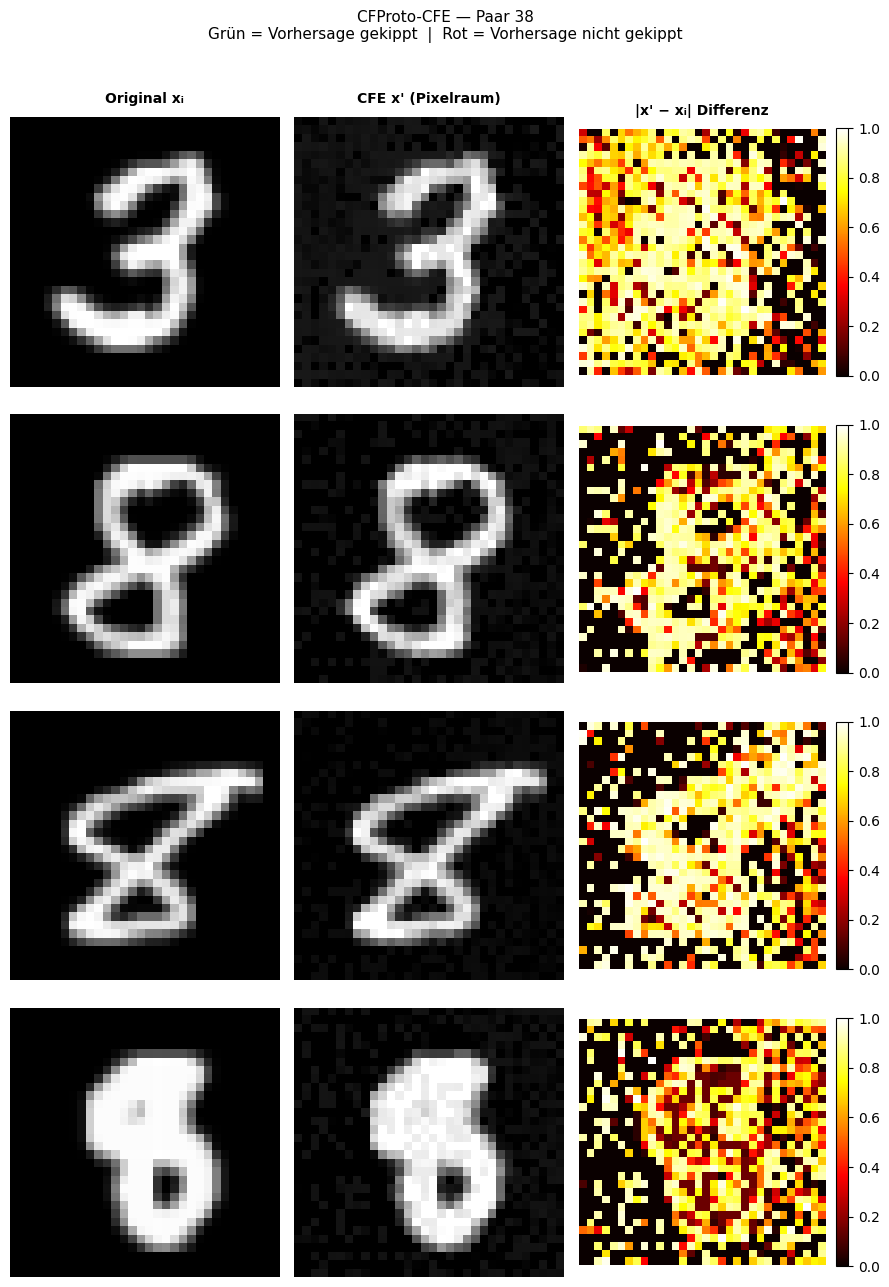

Gespeichert -> /kaggle/working/cfproto_38.png


/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')
/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')
CFProto Evaluation: 100%|██████████| 10/10 [36:03<00:00, 216.36s/it]



Flip Rate (10 Batches): 160/160 = 100.00%
Fester Eval-Satz: 80 Bilder (Seed 42)
Berechne Metriken ueber 80 Bilder (fester Eval-Satz)...
------------------------------------------------------------


Metrik-Evaluation:   0%|          | 0/5 [00:00<?, ?it/s]/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')
/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')
Metrik-Evaluation: 100%|██████████| 5/5 [18:00<00:00, 216.07s/it]


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


...

Berechne Coverage (5 Runs ueber den festen Eval-Satz)...

METRIK-ERGEBNISSE — CFProto-CFE MNIST Paar 38

-- Proximity --
  L1-Distanz:           0.0393  (niedriger = besser)

-- Interpretierbarkeit --
  Sparsity Rate:        0.7093  (niedriger = besser)
  LPIPS (SqueezeNet):   0.0682  (niedriger = besser)

-- Plausibilitaet --
  FID:                  104.27   (niedriger = besser)

-- Funktionalitaet --
  Validity:             38.75%  (hoeher = besser)
  Denoised Validity:    42.50%  (hoeher = besser, sigma=1.0)
  Delta Validity:       -3.75%  (niedriger = besser = weniger adversarial)
  Coverage:             100.00% +/- 0.00%  (hoeher = besser)
  Efficiency:           13.502s / CF  (niedriger = besser)

Ergebnis fuer CFProto / Paar 38 in /kaggle/working/metrics_summary.csv gespeichert.

######################################################################
# CFProto-CFE — Ziffernpaar 49 (4, 9)
######################################################################
Klassifikator-Checkpoi

Embeddings:   0%|          | 0/32 [00:00<?, ?it/s]/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')
/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')
Embeddings: 100%|██████████| 32/32 [00:00<00:00, 56.30it/s]

  Prototyp Klasse 0 (4): 20 Samples
  Prototyp Klasse 1 (9): 20 Samples

Prototypen berechnet:
  Klasse 0 (4): shape=torch.Size([512]), norm=37.03
  Klasse 1 (9): shape=torch.Size([512]), norm=39.24



/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')
/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')


Batch-Groesse   : 16
Flip Rate     : 100.00%  (Ziel: >80%)


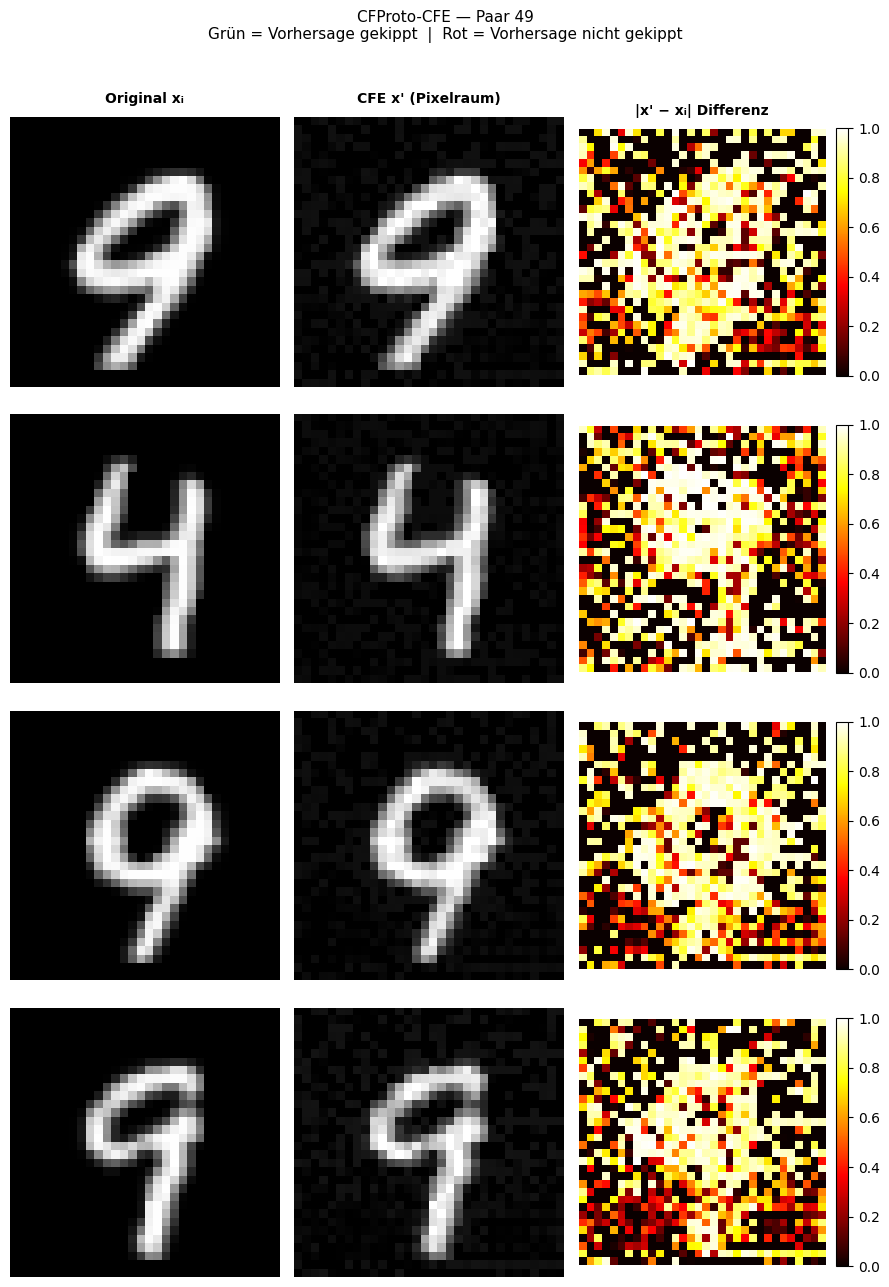

Gespeichert -> /kaggle/working/cfproto_49.png


/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')
/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')
CFProto Evaluation: 100%|██████████| 10/10 [35:48<00:00, 214.81s/it]



Flip Rate (10 Batches): 160/160 = 100.00%
Fester Eval-Satz: 80 Bilder (Seed 42)
Berechne Metriken ueber 80 Bilder (fester Eval-Satz)...
------------------------------------------------------------


Metrik-Evaluation:   0%|          | 0/5 [00:00<?, ?it/s]/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')
/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')
Metrik-Evaluation: 100%|██████████| 5/5 [18:04<00:00, 216.90s/it]
/tmp/ipykernel_23/314522626.py:80: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean, _ = scipy_linalg.sqrtm(sig_r @ sig_f, disp=False)


Berechne Coverage (5 Runs ueber den festen Eval-Satz)...

METRIK-ERGEBNISSE — CFProto-CFE MNIST Paar 49

-- Proximity --
  L1-Distanz:           0.0318  (niedriger = besser)

-- Interpretierbarkeit --
  Sparsity Rate:        0.6777  (niedriger = besser)
  LPIPS (SqueezeNet):   0.0926  (niedriger = besser)

-- Plausibilitaet --
  FID:                  103.83   (niedriger = besser)

-- Funktionalitaet --
  Validity:             57.50%  (hoeher = besser)
  Denoised Validity:    0.00%  (hoeher = besser, sigma=1.0)
  Delta Validity:       57.50%  (niedriger = besser = weniger adversarial)
  Coverage:             100.00% +/- 0.00%  (hoeher = besser)
  Efficiency:           13.554s / CF  (niedriger = besser)

Ergebnis fuer CFProto / Paar 49 in /kaggle/working/metrics_summary.csv gespeichert.

######################################################################
# CFProto-CFE — Ziffernpaar 56 (5, 6)
######################################################################
Klassifikator-Checkpoin

Embeddings:   0%|          | 0/32 [00:00<?, ?it/s]/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')
/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')
Embeddings: 100%|██████████| 32/32 [00:00<00:00, 54.07it/s]

  Prototyp Klasse 0 (5): 20 Samples
  Prototyp Klasse 1 (6): 20 Samples

Prototypen berechnet:
  Klasse 0 (5): shape=torch.Size([512]), norm=48.22
  Klasse 1 (6): shape=torch.Size([512]), norm=37.69



/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')
/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')


Batch-Groesse   : 16
Flip Rate     : 100.00%  (Ziel: >80%)


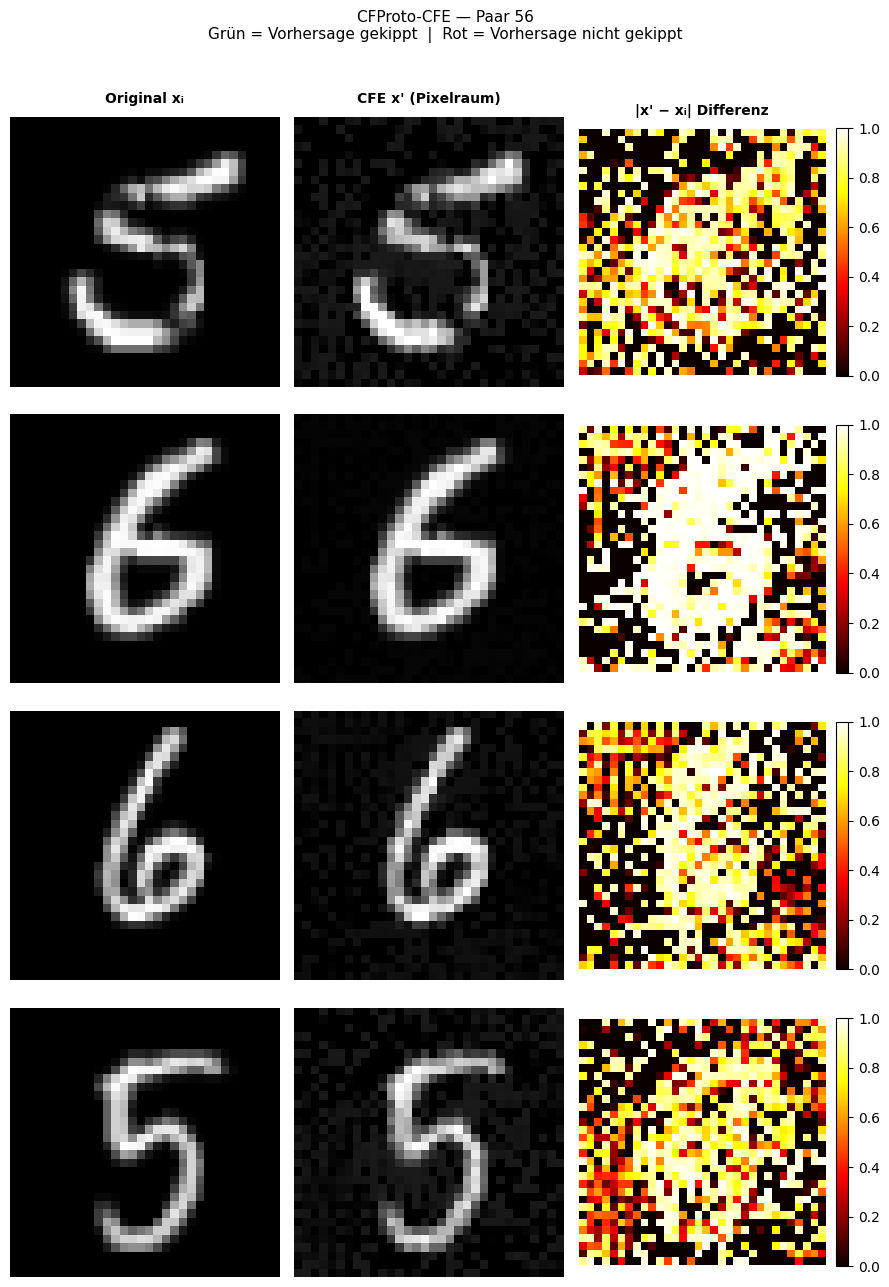

Gespeichert -> /kaggle/working/cfproto_56.png


/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')
/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')
CFProto Evaluation: 100%|██████████| 10/10 [35:50<00:00, 215.02s/it]



Flip Rate (10 Batches): 160/160 = 100.00%
Fester Eval-Satz: 80 Bilder (Seed 42)
Berechne Metriken ueber 80 Bilder (fester Eval-Satz)...
------------------------------------------------------------


Metrik-Evaluation:   0%|          | 0/5 [00:00<?, ?it/s]/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')
/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')
Metrik-Evaluation: 100%|██████████| 5/5 [17:57<00:00, 215.48s/it]


Berechne Coverage (5 Runs ueber den festen Eval-Satz)...

METRIK-ERGEBNISSE — CFProto-CFE MNIST Paar 56

-- Proximity --
  L1-Distanz:           0.0418  (niedriger = besser)

-- Interpretierbarkeit --
  Sparsity Rate:        0.6886  (niedriger = besser)
  LPIPS (SqueezeNet):   0.1159  (niedriger = besser)

-- Plausibilitaet --
  FID:                  99.26   (niedriger = besser)

-- Funktionalitaet --
  Validity:             46.25%  (hoeher = besser)
  Denoised Validity:    3.75%  (hoeher = besser, sigma=1.0)
  Delta Validity:       42.50%  (niedriger = besser = weniger adversarial)
  Coverage:             100.00% +/- 0.00%  (hoeher = besser)
  Efficiency:           13.465s / CF  (niedriger = besser)

Ergebnis fuer CFProto / Paar 56 in /kaggle/working/metrics_summary.csv gespeichert.

Alle 3 Ziffernpaare durchgelaufen.


In [10]:
all_results = []
for _pk in TASK_PAIRS:
    all_results.append(run_cfproto_pipeline(_pk))

print('\n' + '=' * 70)
print('Alle 3 Ziffernpaare durchgelaufen.')
print('=' * 70)


## 10. Mittelwert ueber alle 3 Ziffernpaare

In [11]:
import pandas as pd

numeric_cols = ['l1', 'sparsity_rate', 'lpips', 'fid', 'validity', 'denoised_validity',
                'delta_validity', 'coverage_mean', 'coverage_std', 'efficiency_sec']

df = pd.DataFrame(all_results)
mean_row = {'method': METHOD, 'pair_key': 'MEAN', 'digit_pair': 'Mittelwert ueber alle 3 Paare'}
for col in numeric_cols:
    vals = pd.to_numeric(df[col], errors='coerce')
    mean_row[col] = round(float(vals.mean()), 4)
mean_row['n_eval'] = N_EVAL_IMAGES
mean_row['eval_seed'] = EVAL_SEED

SUMMARY_PATH = os.path.join(OUT_DIR, 'metrics_summary.csv')
existing_rows = []
if os.path.exists(SUMMARY_PATH):
    with open(SUMMARY_PATH, newline='') as f:
        existing_rows = list(__import__('csv').DictReader(f))
existing_rows = [r for r in existing_rows if not (r['method'] == METHOD and r['pair_key'] == 'MEAN')]
existing_rows.append({k: str(v) for k, v in mean_row.items()})
fieldnames = list(existing_rows[0].keys()) if existing_rows else list(mean_row.keys())
with open(SUMMARY_PATH, 'w', newline='') as f:
    writer = __import__('csv').DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(existing_rows)

print('=' * 70)
print(f'METRIK-ERGEBNISSE — CFProto MNIST — MITTELWERT ueber alle 3 Ziffernpaare (N={len(all_results)})')
print('=' * 70)
print(f"\n-- Proximity --")
print(f"  L1-Distanz:           {mean_row['l1']:.4f}")
print(f"\n-- Interpretierbarkeit --")
print(f"  Sparsity Rate:        {mean_row['sparsity_rate']:.4f}")
print(f"  LPIPS (SqueezeNet):   {mean_row['lpips']:.4f}")
print(f"\n-- Plausibilitaet --")
print(f"  FID:                  {mean_row['fid']:.2f}")
print(f"\n-- Funktionalitaet --")
print(f"  Validity:             {mean_row['validity']:.2%}")
print(f"  Denoised Validity:    {mean_row['denoised_validity']:.2%}")
print(f"  Delta Validity:       {mean_row['delta_validity']:.2%}")
print(f"  Coverage:             {mean_row['coverage_mean']:.2%} +/- {mean_row['coverage_std']:.2%}")
print(f"  Efficiency:           {mean_row['efficiency_sec']:.3f}s / CF")
print('=' * 70)

df_display = pd.DataFrame(all_results + [mean_row])
df_display


METRIK-ERGEBNISSE — CFProto MNIST — MITTELWERT ueber alle 3 Ziffernpaare (N=3)

-- Proximity --
  L1-Distanz:           0.0376

-- Interpretierbarkeit --
  Sparsity Rate:        0.6919
  LPIPS (SqueezeNet):   0.0922

-- Plausibilitaet --
  FID:                  102.45

-- Funktionalitaet --
  Validity:             47.50%
  Denoised Validity:    15.42%
  Delta Validity:       32.08%
  Coverage:             100.00% +/- 0.00%
  Efficiency:           13.507s / CF


,method,pair_key,digit_pair,l1,sparsity_rate,lpips,fid,validity,denoised_validity,delta_validity,coverage_mean,coverage_std,efficiency_sec,n_eval,eval_seed
0,CFProto,38,3-8,0.0393,0.7093,0.0682,104.2700,0.3875,0.4250,-0.0375,1.0,0.0,13.5016,80,42
1,CFProto,49,4-9,0.0318,0.6777,0.0926,103.8300,0.5750,0.0000,0.5750,1.0,0.0,13.5542,80,42
2,CFProto,56,5-6,0.0418,0.6886,0.1159,99.2600,0.4625,0.0375,0.4250,1.0,0.0,13.4654,80,42
3,CFProto,MEAN,Mittelwert ueber alle 3 Paare,0.0376,0.6919,0.0922,102.4533,0.4750,0.1542,0.3208,1.0,0.0,13.5071,80,42
